# Io Reconstruction in the Image Plane

In this notebook I will run through a basic example of an image reconstruction using Method 1 from the [dorito paper](https://arxiv.org/abs/2510.10924).

First we import our relevant libraries, and enable 64-bit float precision and (optionally) GPU usage.

In [1]:
# jax ecosystem
import jax
from jax import numpy as np  # apologies for this, but once you go jax you never go back

jax.config.update("jax_enable_x64", True)  # using 64-bit precision is necessary
jax.config.update("jax_platform_name", "gpu")  # for using GPU (optional)
print(jax.local_devices()[0].device_kind)

NVIDIA GeForce RTX 2080 Ti


In [2]:
import amigo  # for the amigo base model
import dorito  # for image reconstruction
from zodiax.optimisation import sgd, adam  # for gradient descent

# other helpful libraries
import os
from dLux import utils as dlu  # for some optics utils functionality

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


# Loading in

Here we load in the data and relevant files to run the `amigo` model.

In [3]:
path_to_files = "/media/morgana1/snert/max/data/"

# processed "calslope" files from the amigo pipeline
data_path = os.path.join(path_to_files, "JWST/IO/calslope/")

# amigo files
model_cache = os.path.join(path_to_files, "amigo_files/v_0.0.10/")
fisher_path = os.path.join(path_to_files, "amigo_files/fishers/")
output_path = os.path.join(path_to_files, "amigo_files/outputs/IO/")

print("Data files:")
print(os.listdir(data_path), "\n")
print("Amigo model files:")
print(os.listdir(model_cache), "\n")

Data files:
['jw01373017001_04102_00001_nis_calslope.fits', 'jw01373023001_03102_00002_nis_calslope.fits', 'jw01373023001_03102_00003_nis_calslope.fits', 'jw01373023001_03102_00004_nis_calslope.fits', 'jw01373017001_04102_00005_nis_calslope.fits', 'jw01373023001_03102_00001_nis_calslope.fits', 'jw01373017001_04102_00002_nis_calslope.fits', 'jw01373017001_04102_00003_nis_calslope.fits', 'jw01373017001_04102_00004_nis_calslope.fits'] 

Amigo model files:
['jacobians.npy', 'calibration.npy', 'vis_basis.npy', 'calibration_2.npy', 'calibration_1.npy', 'im_basis101_1pix_M.npy'] 



Now we actually load the fits files, and set the bad pixels we want. We also truncate the ramp because the Io data is saturated, and we want to keep the pixel well depth below that of the data which was used to train the `amigo` model. 

In [4]:
EXP_TYPE = "NIS_AMI"
FILTERS = [
    # "F480M",
    "F430M",  # Io only had F430M exposures
    # "F380M",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=FILTERS,
    **kwargs,
)

# Here we load in the fits files
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)

sci_files = []
cal_files = []

# Here we manually set bad pixels in the BADPIX extension of the fits files
for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    # edge bad pixels
    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1

    if not bool(file[0].header["IS_PSF"]):
        file["BADPIX"].data[43, 45] = 1
        file["BADPIX"].data[:, :10] = 1
        file["BADPIX"].data[:, -10:] = 1
        file["BADPIX"].data[:10, :] = 1
        file["BADPIX"].data[-10:, :] = 1
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# Here we truncate the ramp to keen the pixel well depth under 30k
dorito.misc.truncate_files(sci_files, 18)

# Building the model

We are going to have to build the exposures. `dorito` has a `ResolvedFit` class built in, however this will jointly fit all exposures of the same filter. Since we want to capture Io's rotation in a time series, we instead want to *uniquely* fit each epoch. To do this, we will write a child class of `ResolvedFit` and amend the `get_key` method. By adding the `self.key` to the `log_dist` parameter key, this ensures each exposure will fit a unique distribution. In the `ResolvedFit` class, it is instead set just to `self.filter`, which is common for all the exposures and hence they will share the same parameter.

`DynamicResolvedFit` is also built into `dorito`, but it is useful to show how the classes are constructed. Once you get comfortable with setting the `get_key` class, `amigo` makes it very easy to quickly change the parameter fitting hierarchy.

In [5]:
class DynamicResolvedFit(dorito.model_fits.ResolvedFit):
    """
    Model fit for resolved sources where each exposure has a different
    intensity distribution.
    """

    def get_key(self, param):
        match param:
            case "log_dist":
                return "_".join([self.key, self.filter])

        return super().get_key(param)

Now we will build the exposures and model. Today, to keep this simple, we will just fit two of the five Io exposures, and use one of the calibrator exposures.

In [6]:
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()  # helper function

# just two science exposures and one calibrator for this demo
sci_exps = [DynamicResolvedFit(file) for file in sci_files[0:2]]
cal_exps = [amigo.model_fits.PointFit(file) for file in cal_files[0:1]]
exps = sci_exps + cal_exps

# building the model
source_size = 101  # pixels
model = dorito.models.ResolvedAmigoModel(
    exposures=exps,
    optics=amigo.optical_models.AMIOptics(),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(model_cache + "calibration.npy"),
    param_initers={
        "distribution": np.ones((source_size, source_size)) / source_size**2
    },
)

Let's have a look how the model fits the data at our initial guesses (it should be terrible)!

File 01373_017_02_04_1
Star IO
Filter F430M
nints 100
ngroups 18



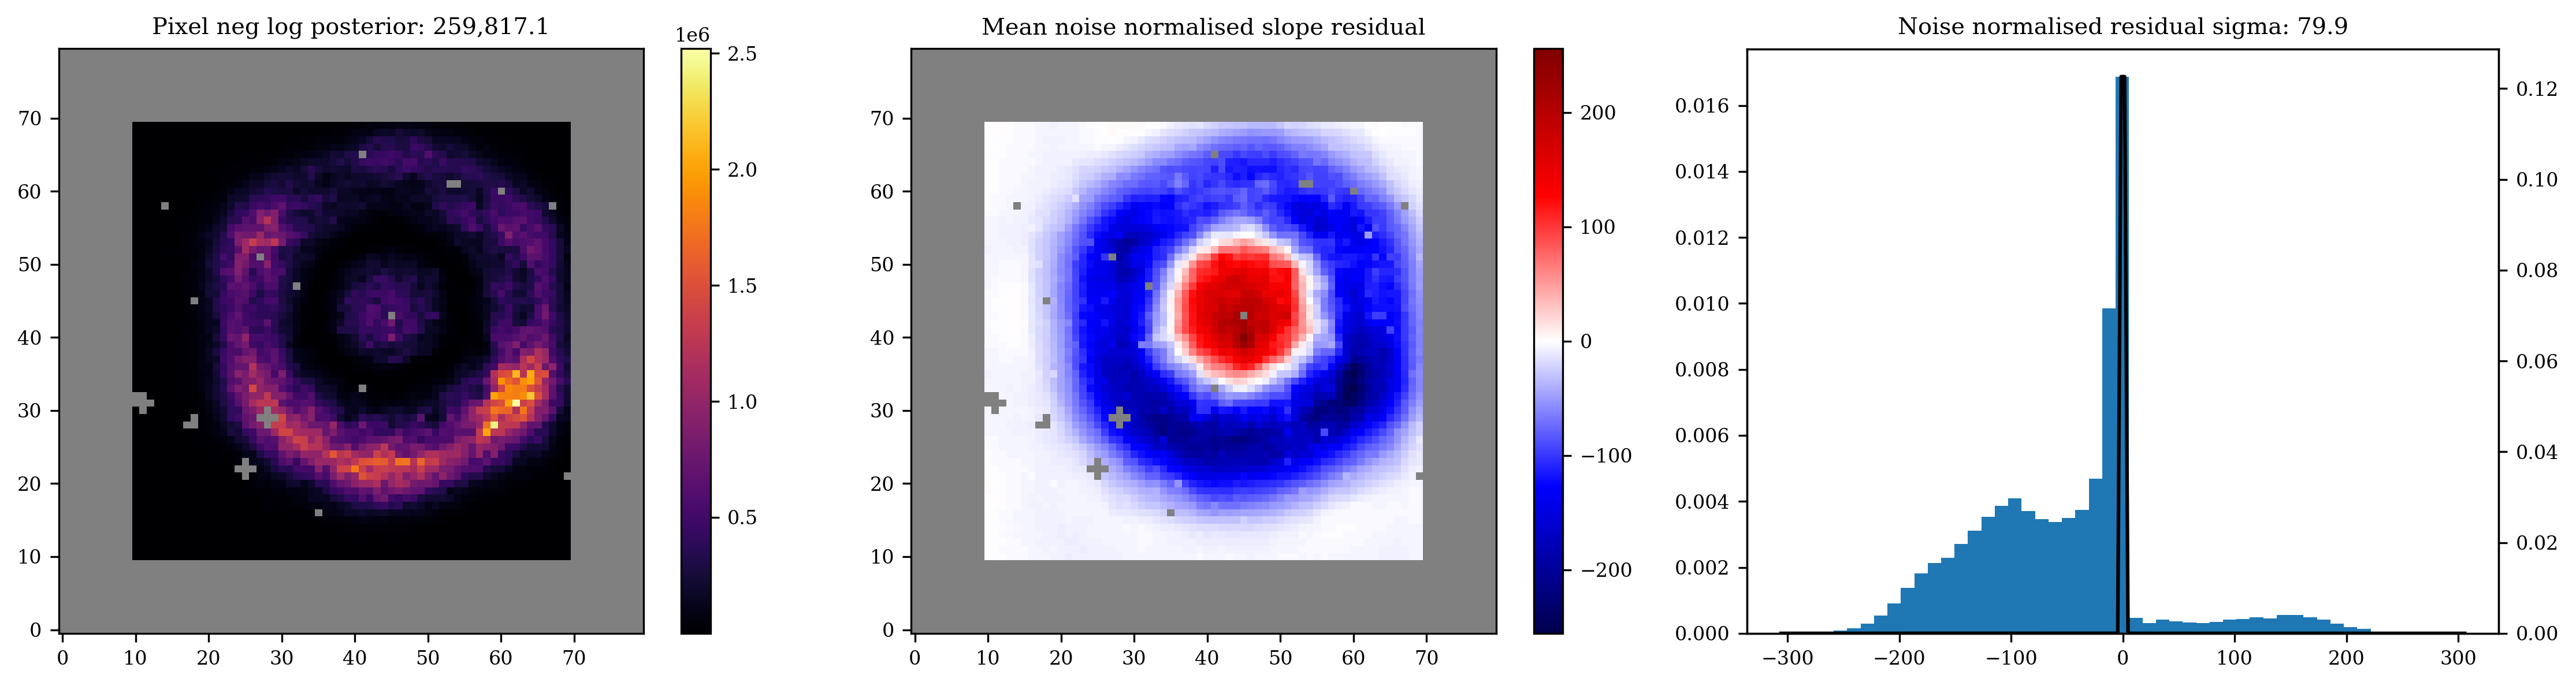

File 01373_017_02_04_2
Star IO
Filter F430M
nints 100
ngroups 18



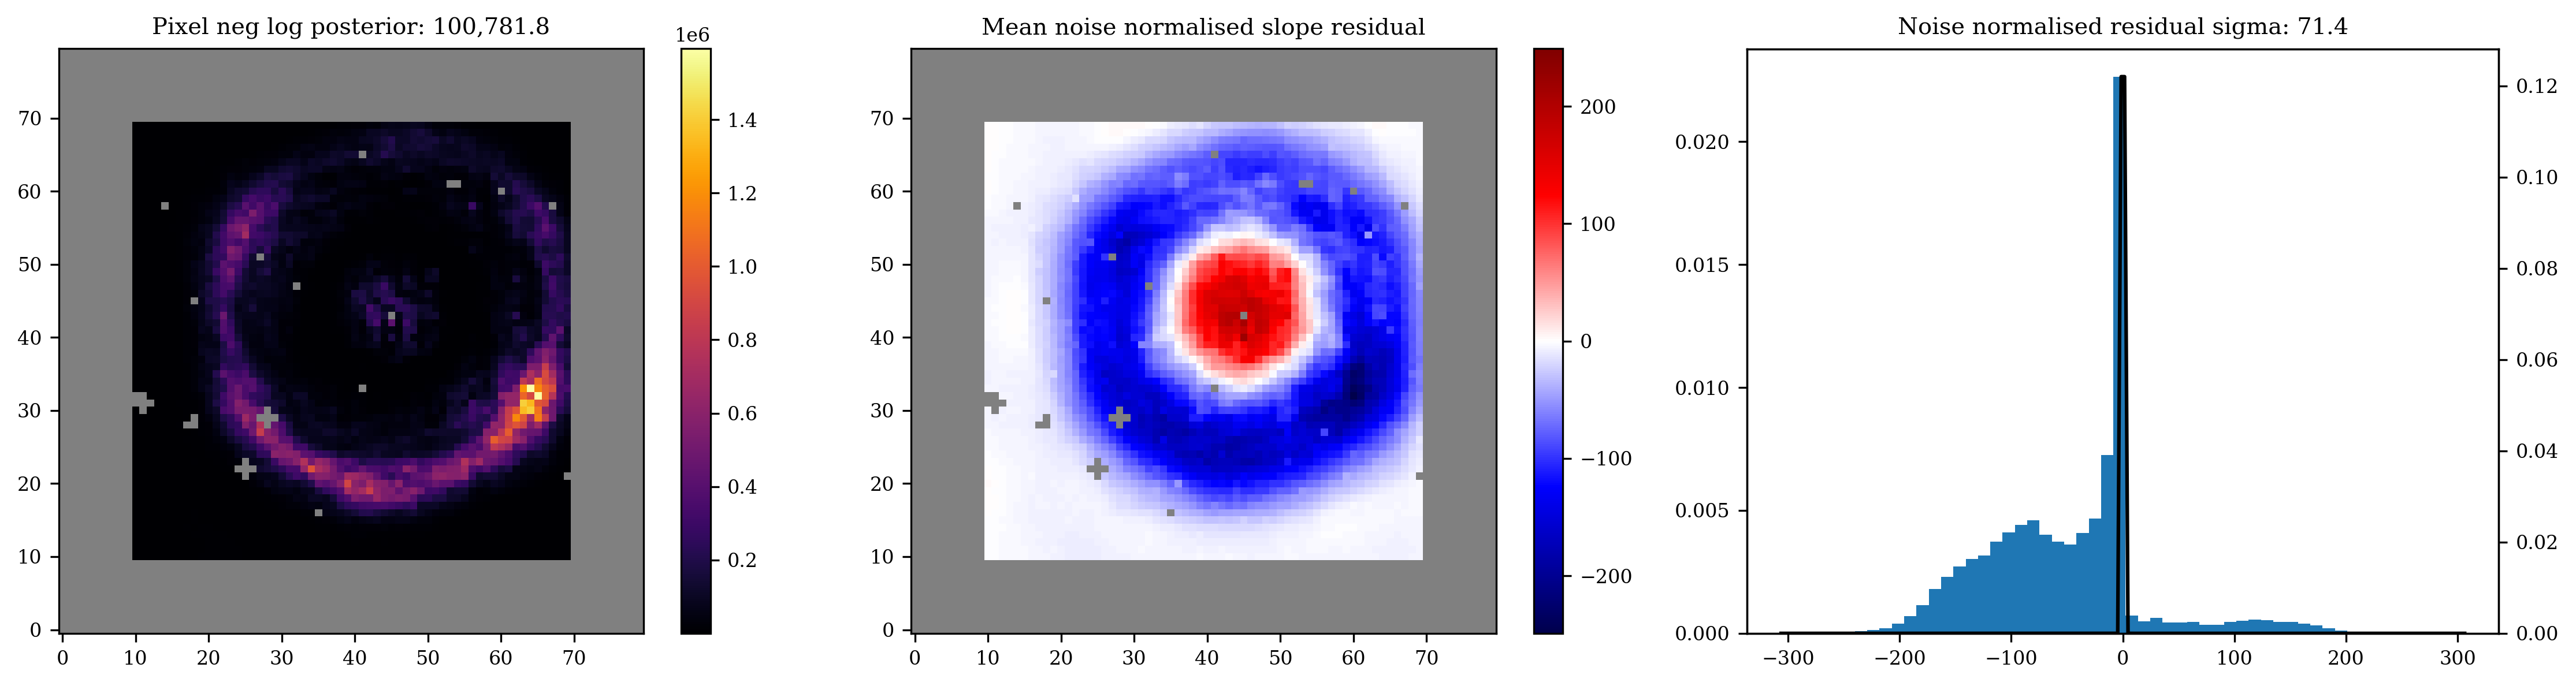

File 01373_023_02_03_1
Star HD 228337
Filter F430M
nints 8
ngroups 12



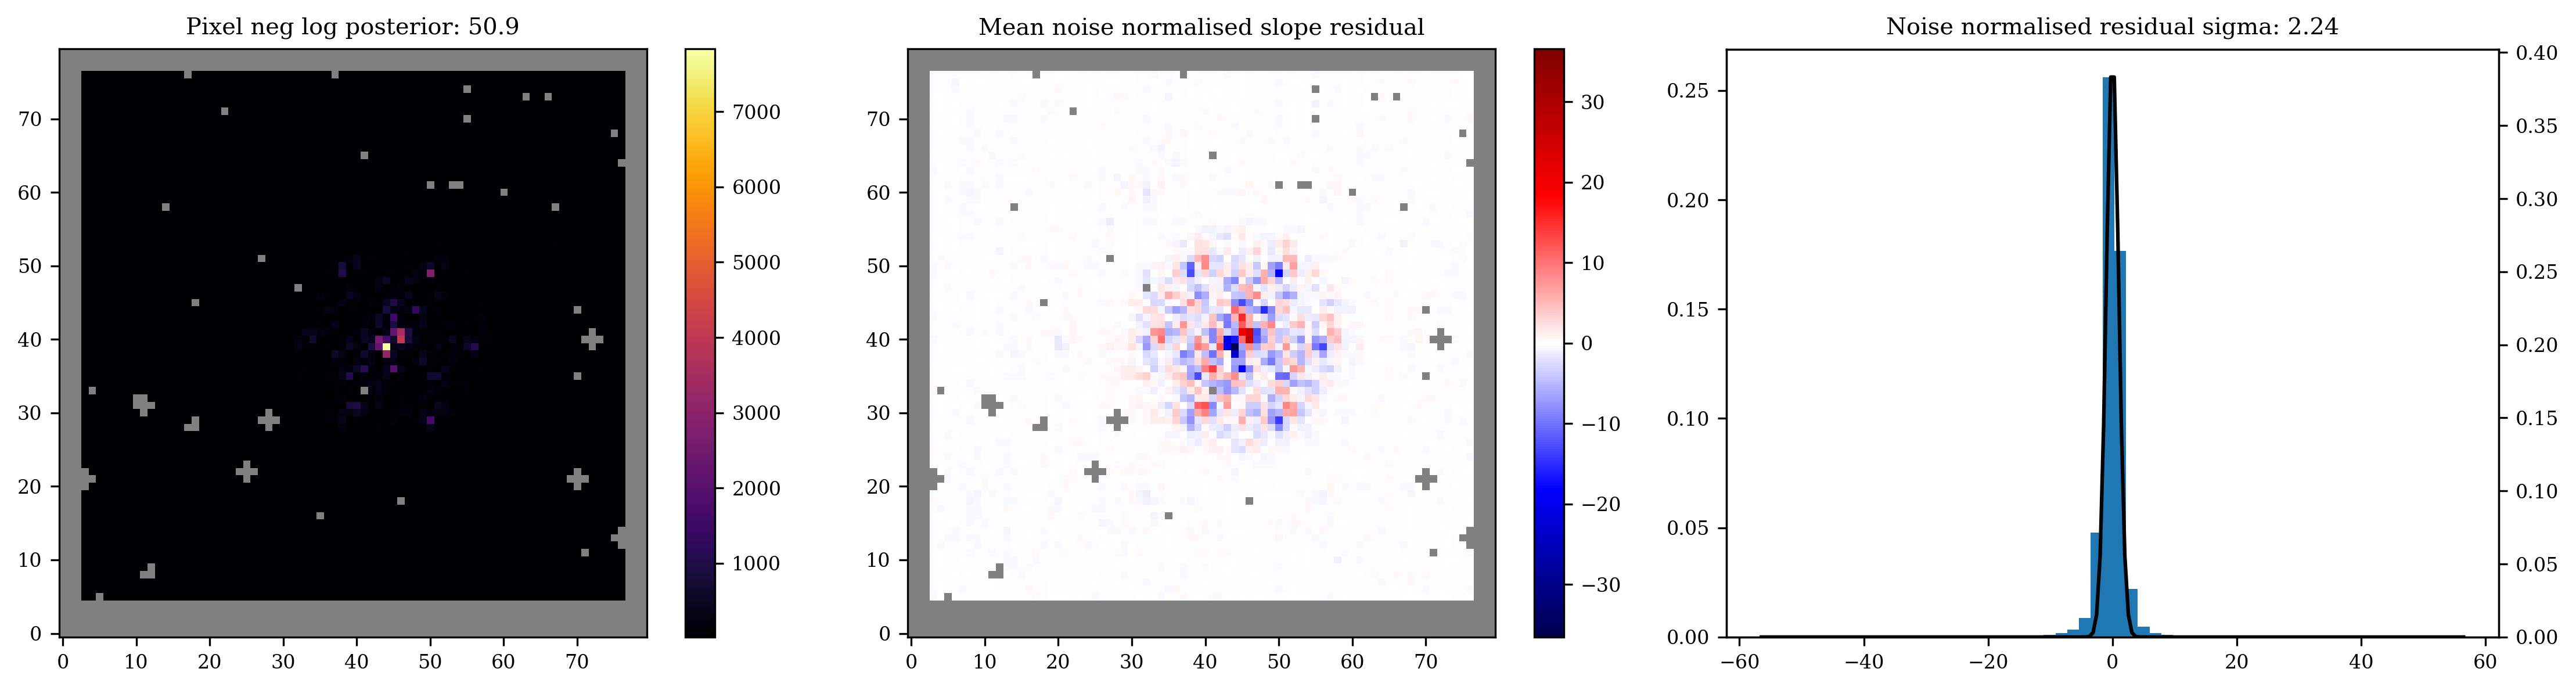

In [7]:
for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(model, exp)

# Optimisation Stage: Gradient Descent

We now will fit the model using gradient descent, specifically using the `optax` library. Let's set some things up first.

Firstly we have our `config` dictionary. You can see we are using a mixture of stochastic gradient descent and the adam optimiser. The `sgd` and `adam` functions from `zodiax` are just wrappers around the respective `optax` functions which allow for easy piecewise learning rate schedules.

For example, `sgd(lr=100, start=50)` will cause a parameter to start fitting after 50 epochs with a learning rate of 100.

In [8]:
config = {
    "positions": sgd(lr=4e-2, start=0),
    "fluxes": sgd(2e-2, 0),
    "aberrations": sgd(5e0, 4),
    "spectra": sgd(1e-1, 10),
    "log_dist": adam(5e-2, 20),
}

Next we define a `norm_fn` or normalisation function, and a `grad_fn` or gradient function. These functions are applied each iteration of the fitting loop to the parameters or the parameter gradients respectively.

## Normalisation function

Because the source distribution values are covariant with the flux parameter, we want to normalise the source distribution every epoch so it will sum to unity.
Additionally, if the `spectra` parameter wanders outside of $[-1, 1]$, everything will turn to `NaN`. To prevent this, we simply clip the value to $[-0.8, 0.8]$ to be extra safe.


In [9]:
def norm_fn(model_params, args):
    params = model_params.params
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist
            params["log_dist"][k] = np.log10(distribution / distribution.sum())

    if "spectra" in params.keys():
        spectra = jax.tree.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args

## Gradient function
Because we are fitting the Io science exposures separately, they do not mutually constrain the position of the source distribution array. Because of this, we do not fit the positions of the science exposures, as the initial guess will be sufficient to place them in the correct part of the detector. We implement this by simply multiplying the gradients by zero in the `grad_fn`.

I have also observed when fitting Io that the gradients of `spectra` for the science and calibrator exposures tend to be quite different. Because of this, in the `grad_fn` I reduce the gradients only for the science exposures by a heuristic factor.


In [10]:
sci_pos_keys = []
sci_spc_keys = []
for exp in exps:
    if not exp.calibrator:
        sci_pos_keys.append(exp.map_param("positions"))
        sci_spc_keys.append(exp.map_param("spectra"))


def grad_fn(model, grads, args):
    # Nuke the position gradients for the science exposures
    if "positions" in config.keys():
        grads = grads.multiply(sci_pos_keys, 0.0)

    # Reduce spectra gradients for the science exposures
    if "spectra" in config.keys():
        grads = grads.multiply(sci_spc_keys, 1e-2)
    return grads, args

## Regularisation

`dorito` has some common image regularisers built in. Here we will use total variation (`dorito.stats.TV`), which we put into the `args dictionary` which we will pass to our `Trainer` class.

For this to work we will need to also pass the `dorito.stats.ramp_regularised_loss_fn` as the loss function to the `Trainer` class, as the default `amigo` loss function knows not of regularisation.

In [11]:
args = {"reg_dict": {"TV": (5e0, dorito.stats.TV)}}

## Fitting
We are almost ready to fit. Here we initialise the `Trainer` class from `amigo` and populate the Fisher matrices. These Fisher matrices are not crucial: they are simply pre-calculated matrices which scale the loss space in order to improve convergence, but with plenty of learning rate tweaking you will reach the same result. This is the case for the `log_dist` parameter which does not have any pre-calculated matrices!

Lastly, we perform the fit!

In [12]:
n_epoch = 1000

trainer = amigo.fitting.Trainer(
    loss_fn=dorito.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(fisher_path),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    model,
    exps,
    hessians=load_dict(model_cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys()],
)

print("Number of exposures: ", len(exps))

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=exps,
    args=args,
)

Populating fishers...
KeyError: log_dist not in hessians for 01373_017_02_04_1, skipped
KeyError: log_dist not in hessians for 01373_017_02_04_2, skipped
KeyError: log_dist not in hessians for 01373_023_02_03_1, skipped
Number of exposures:  3


  0%|          | 0/1000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 120,196.88
Estimated run time: 0:20:16
Full Time: 0:21:54
Final Loss: 24.42


# Results

Let's have a look at how our fit went.

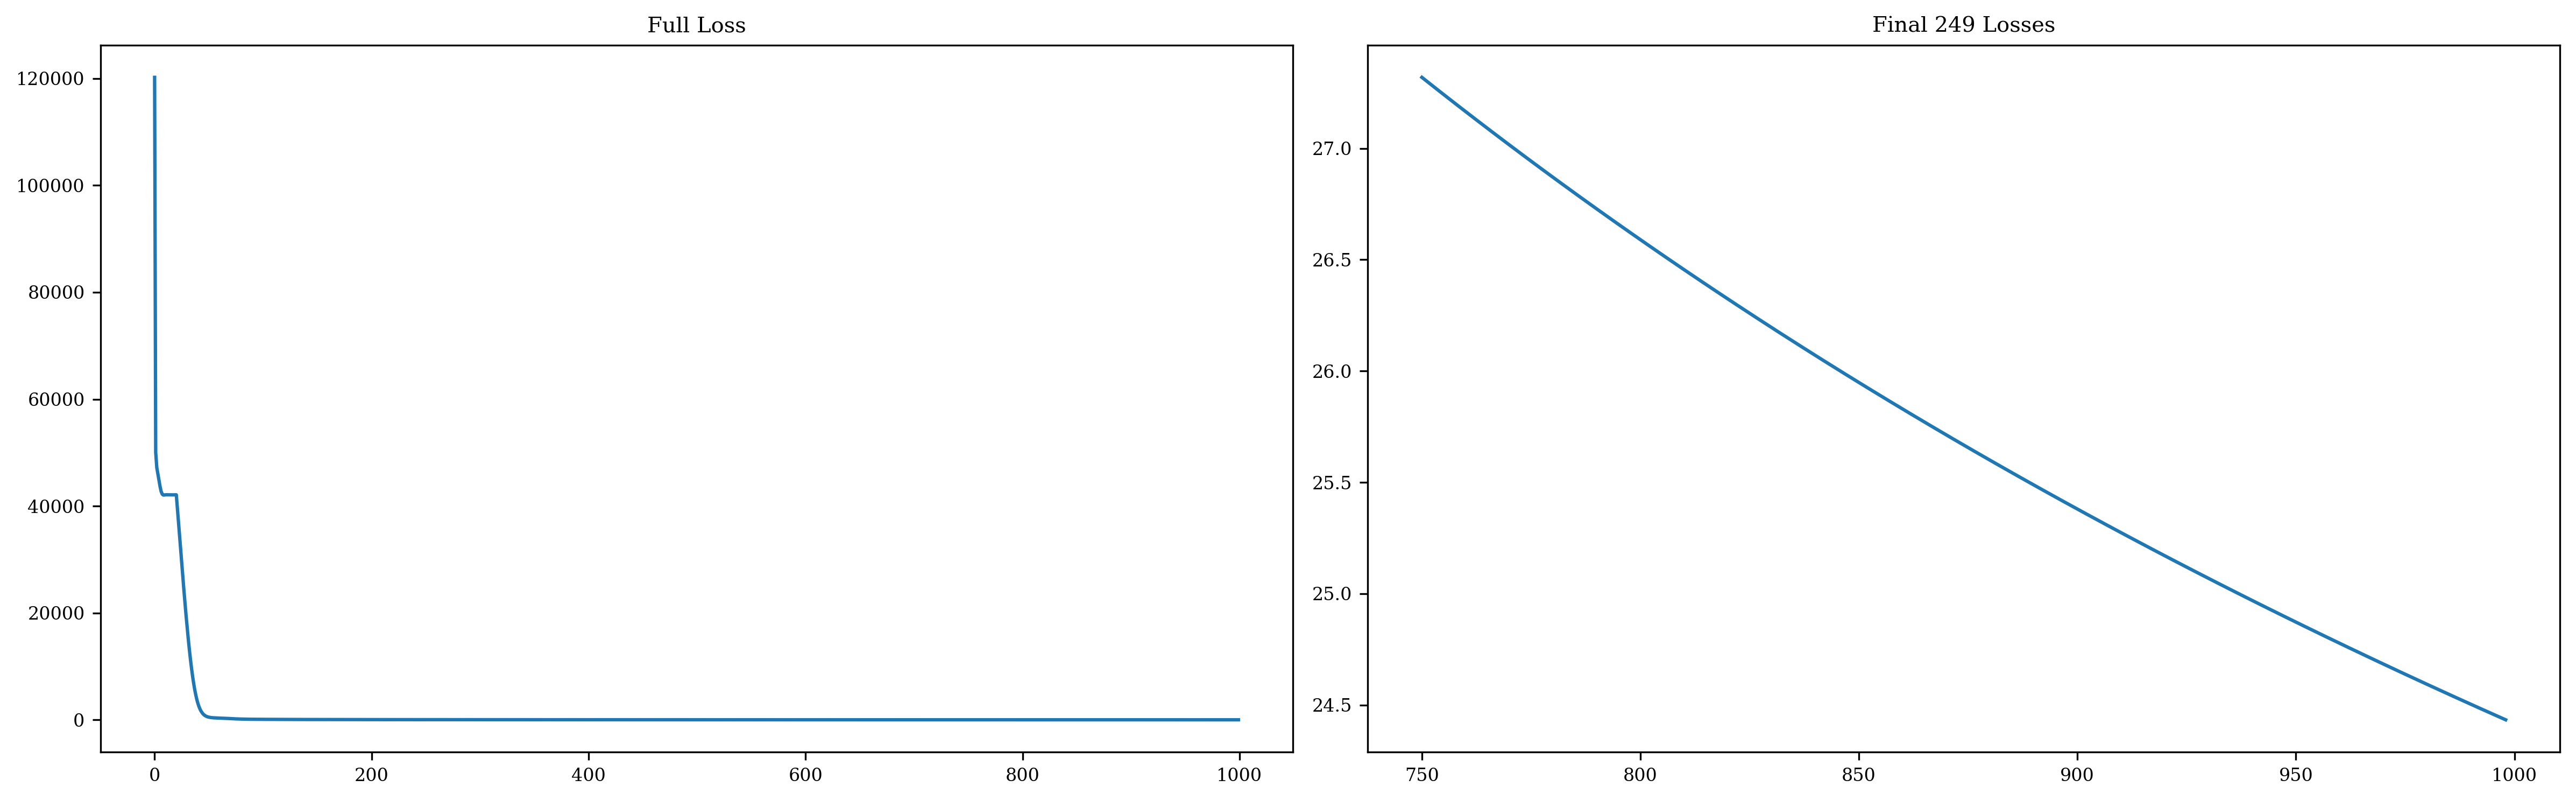

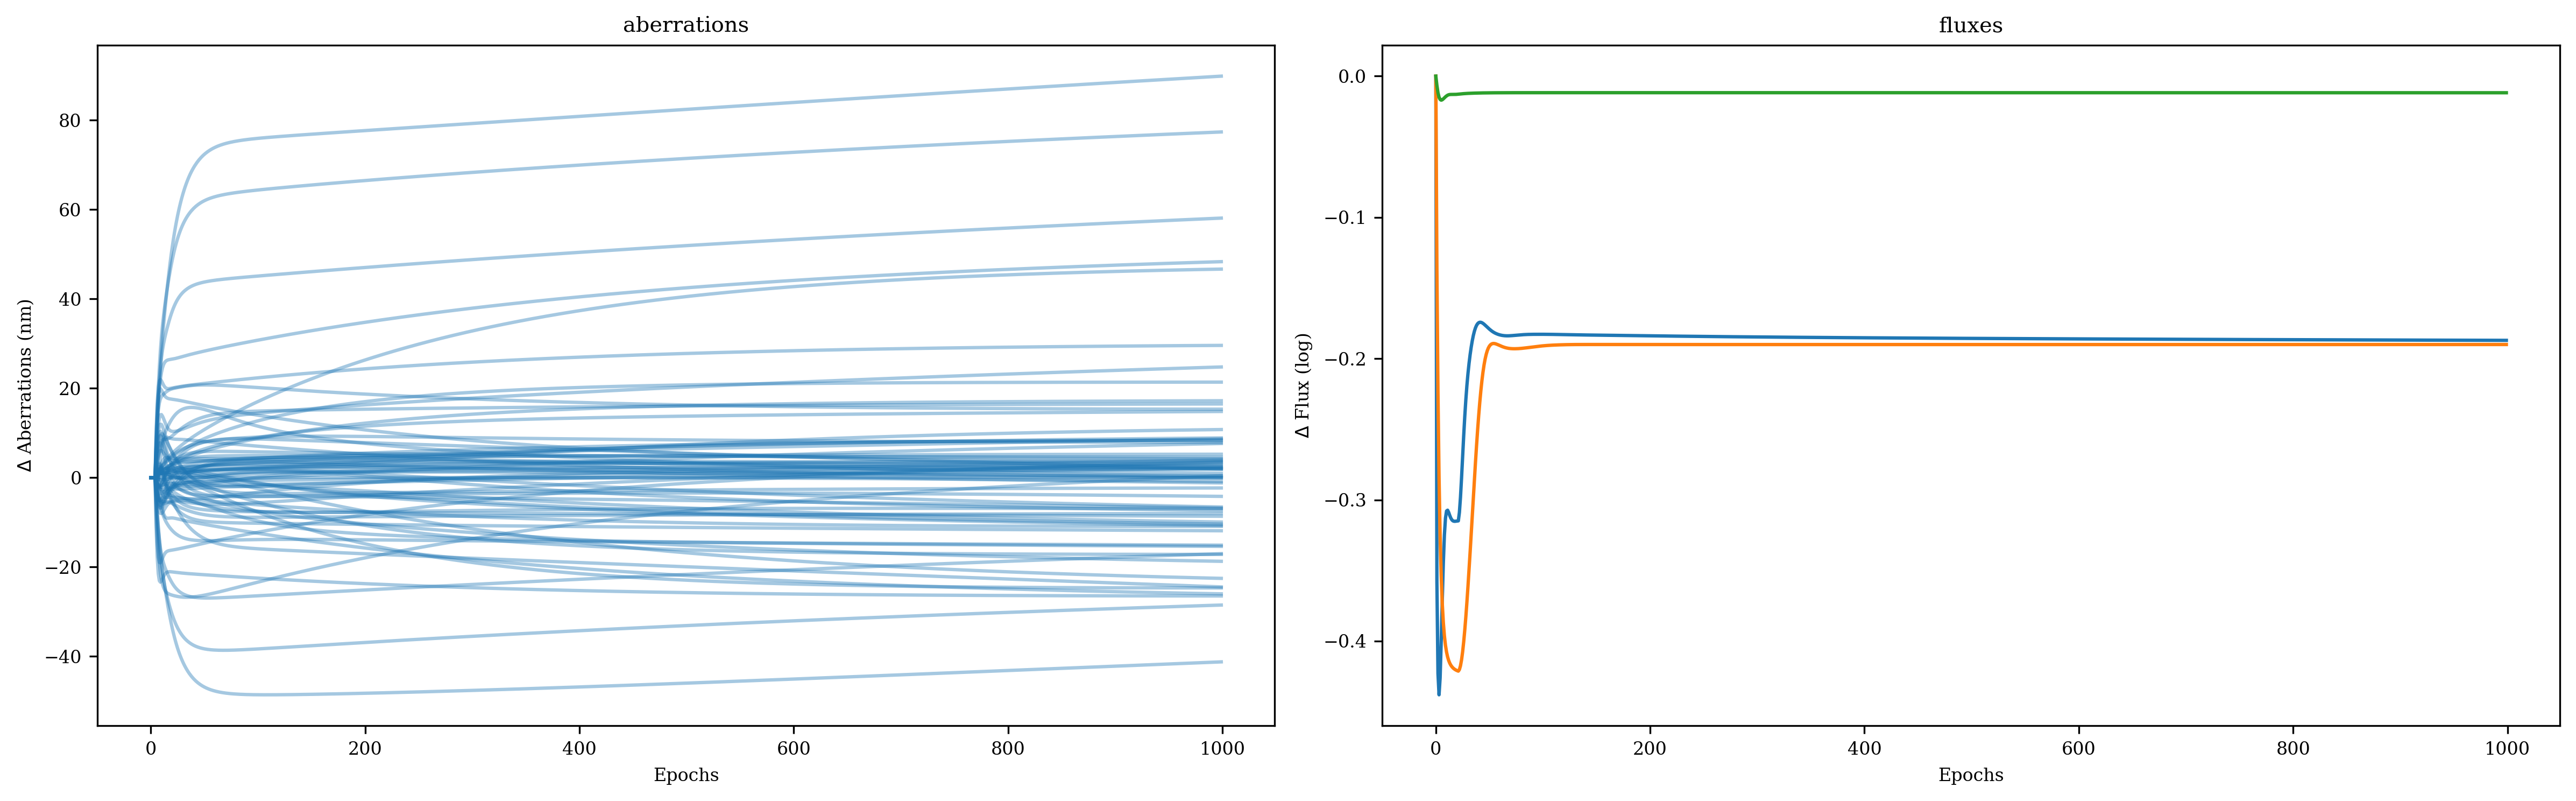

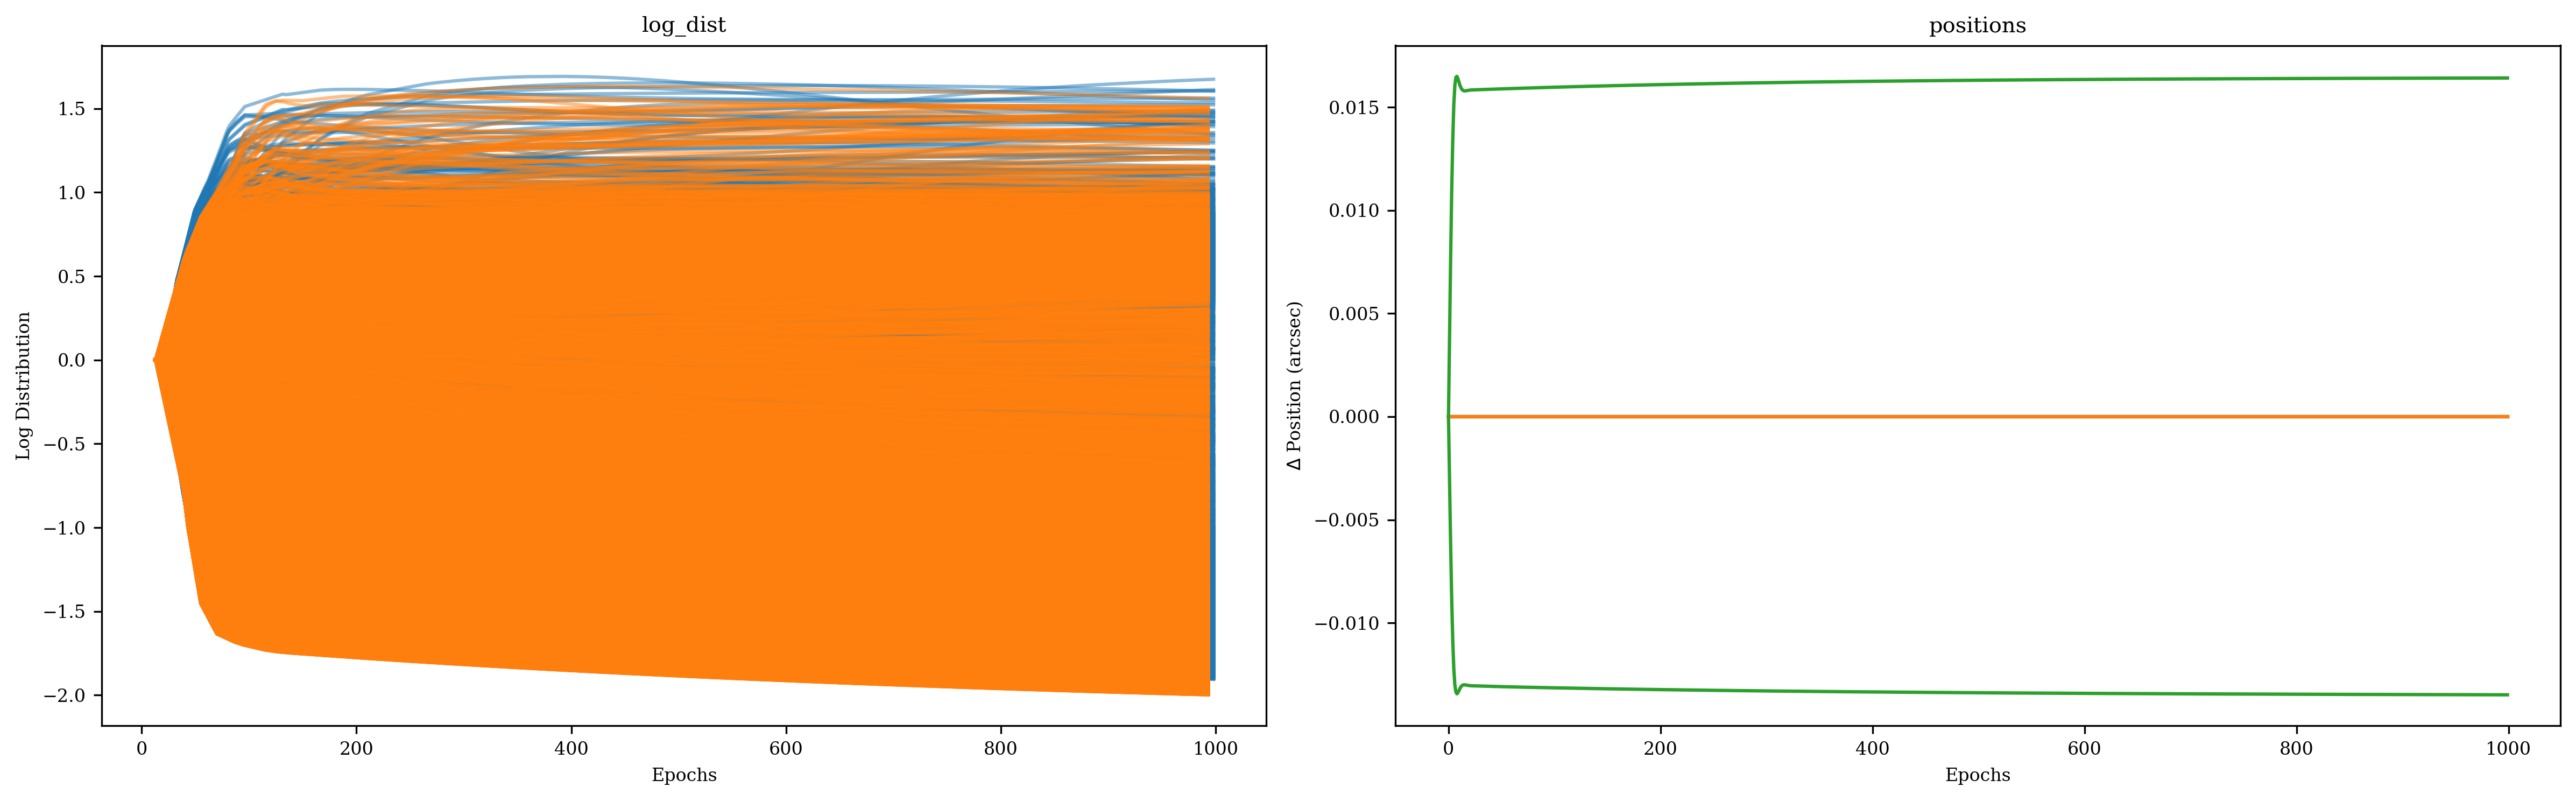

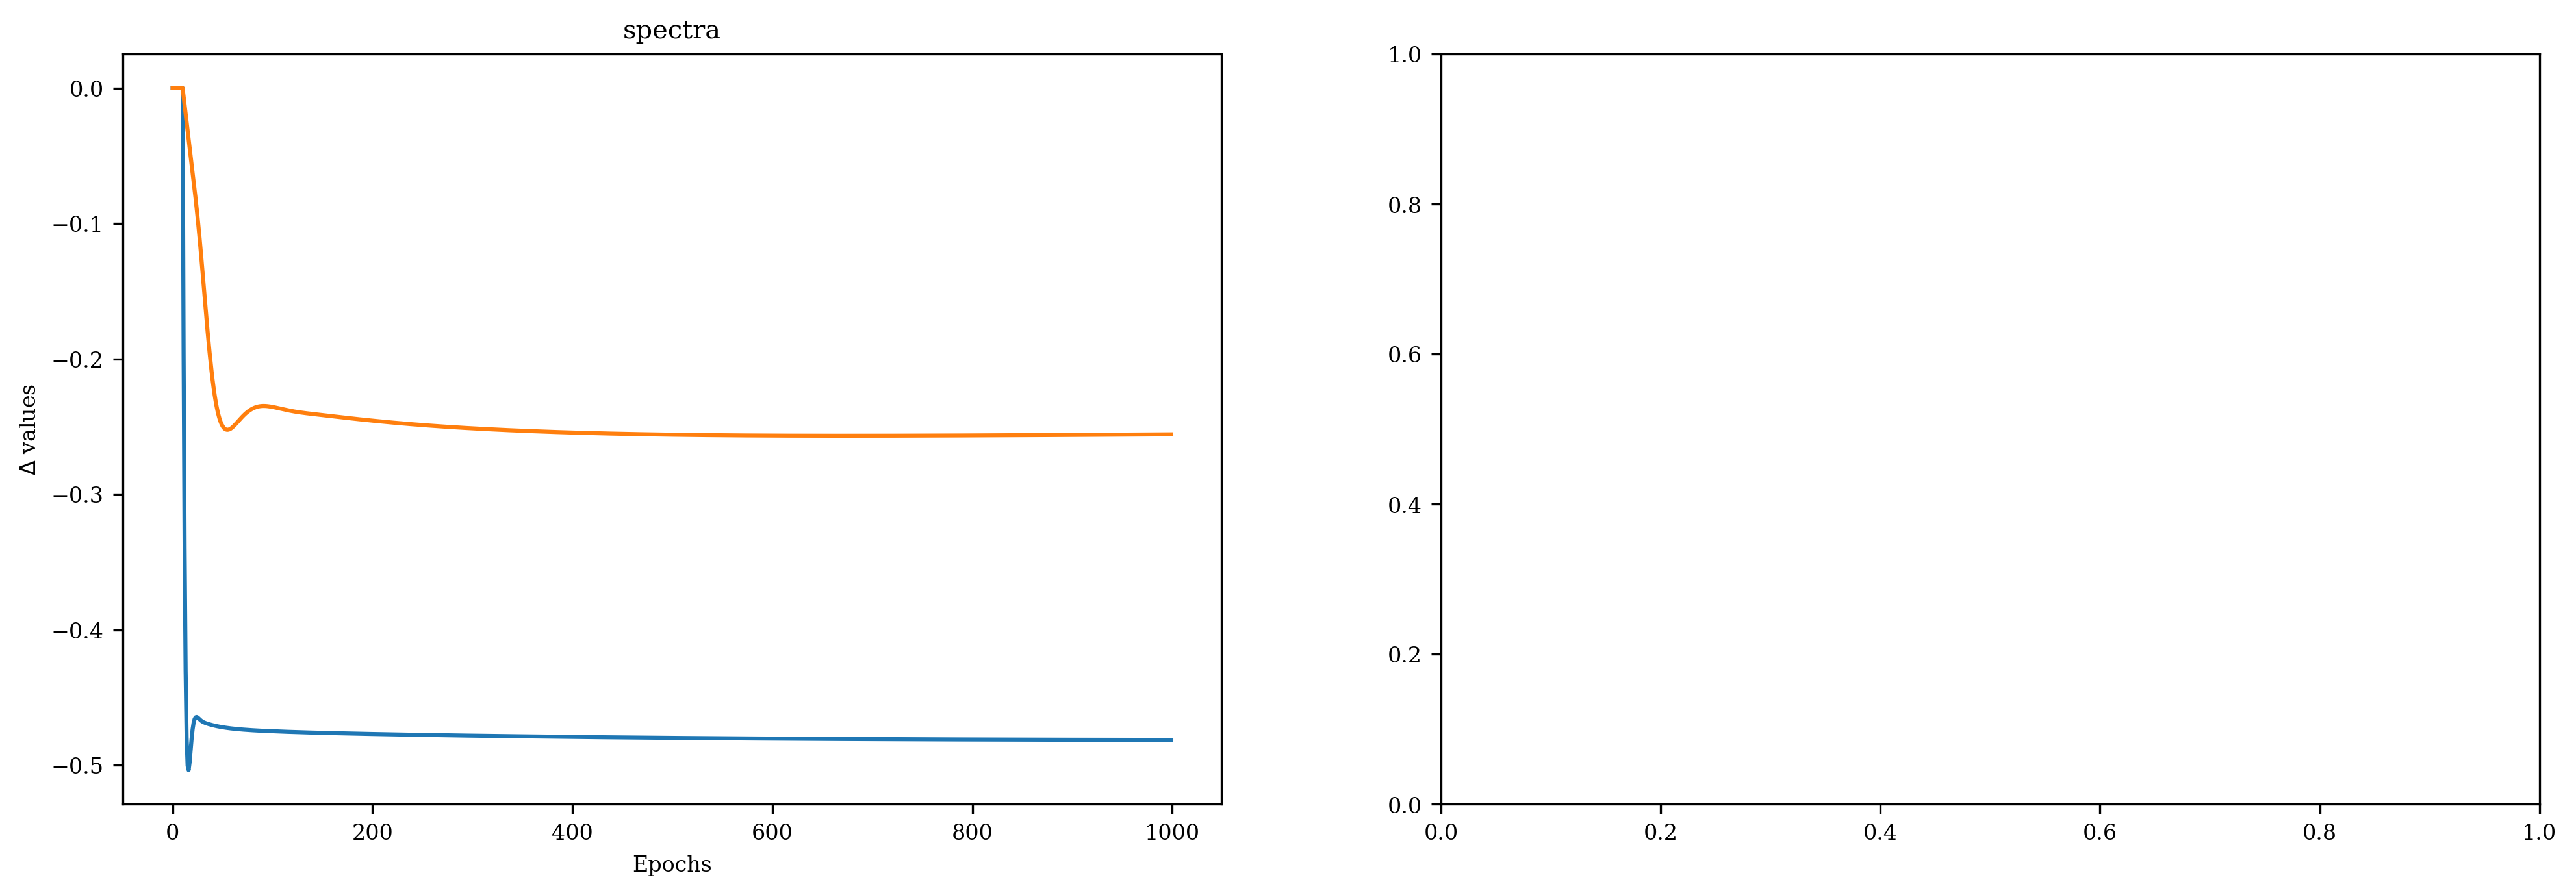

File 01373_017_02_04_1
Star IO
Filter F430M
nints 100
ngroups 18



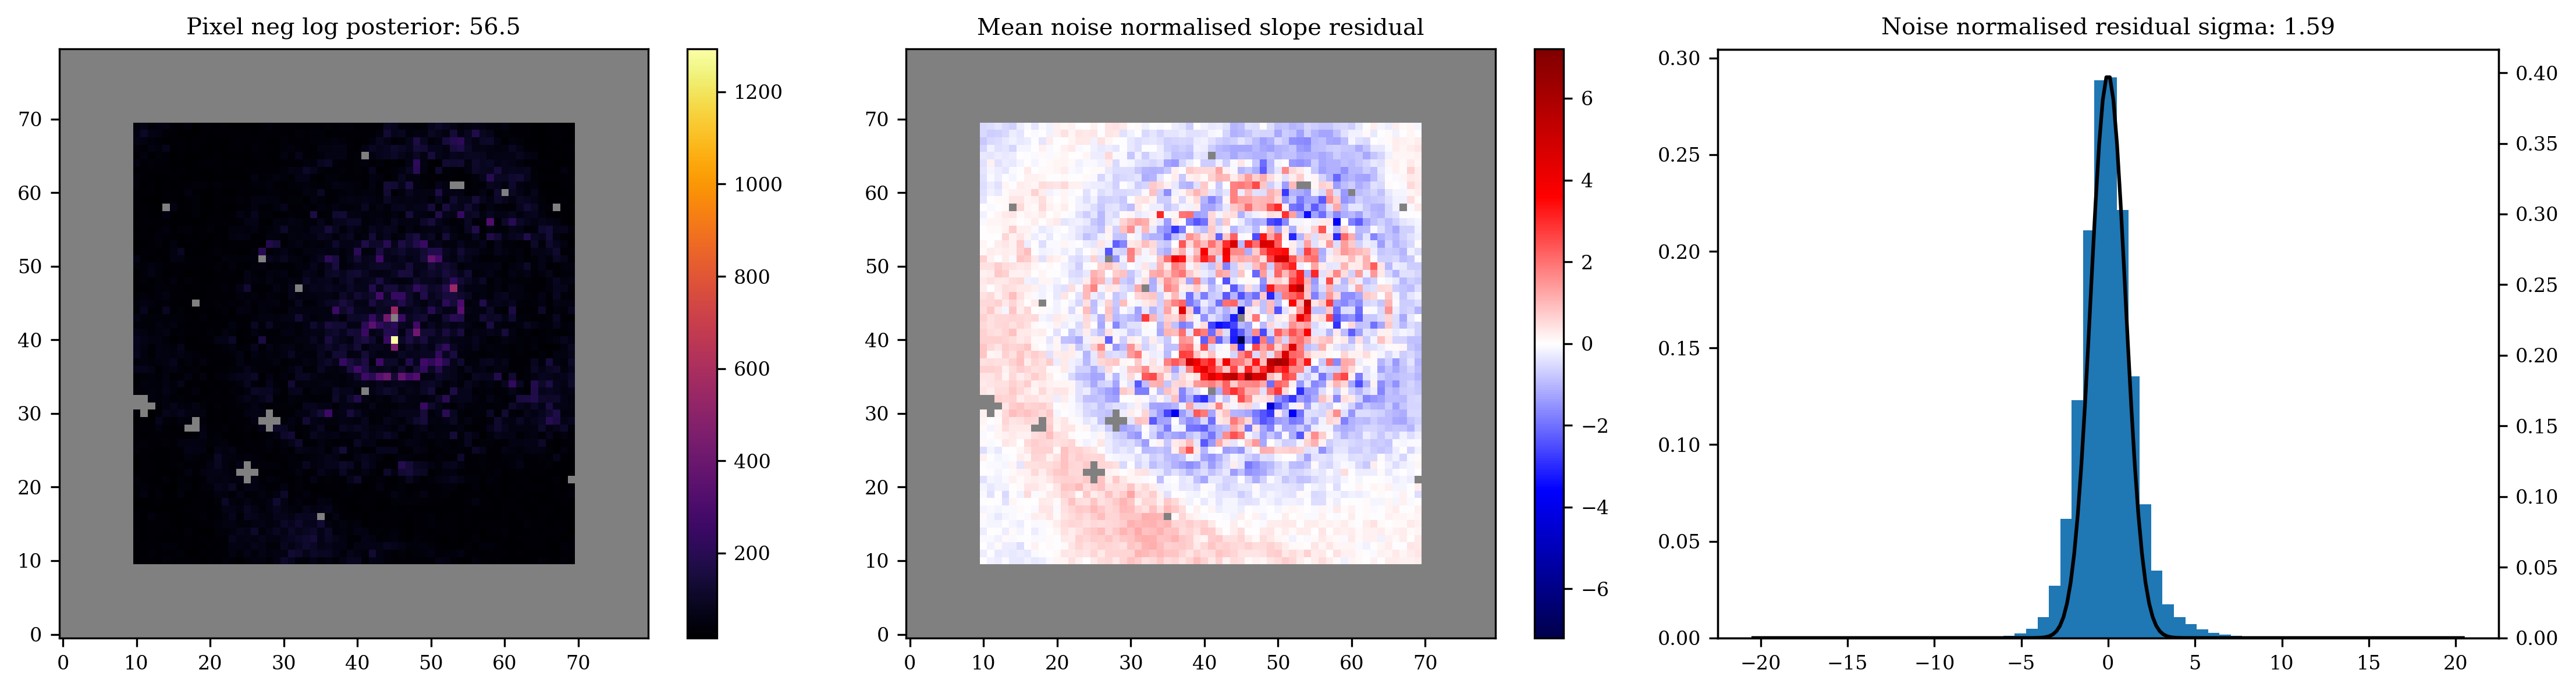

File 01373_017_02_04_2
Star IO
Filter F430M
nints 100
ngroups 18



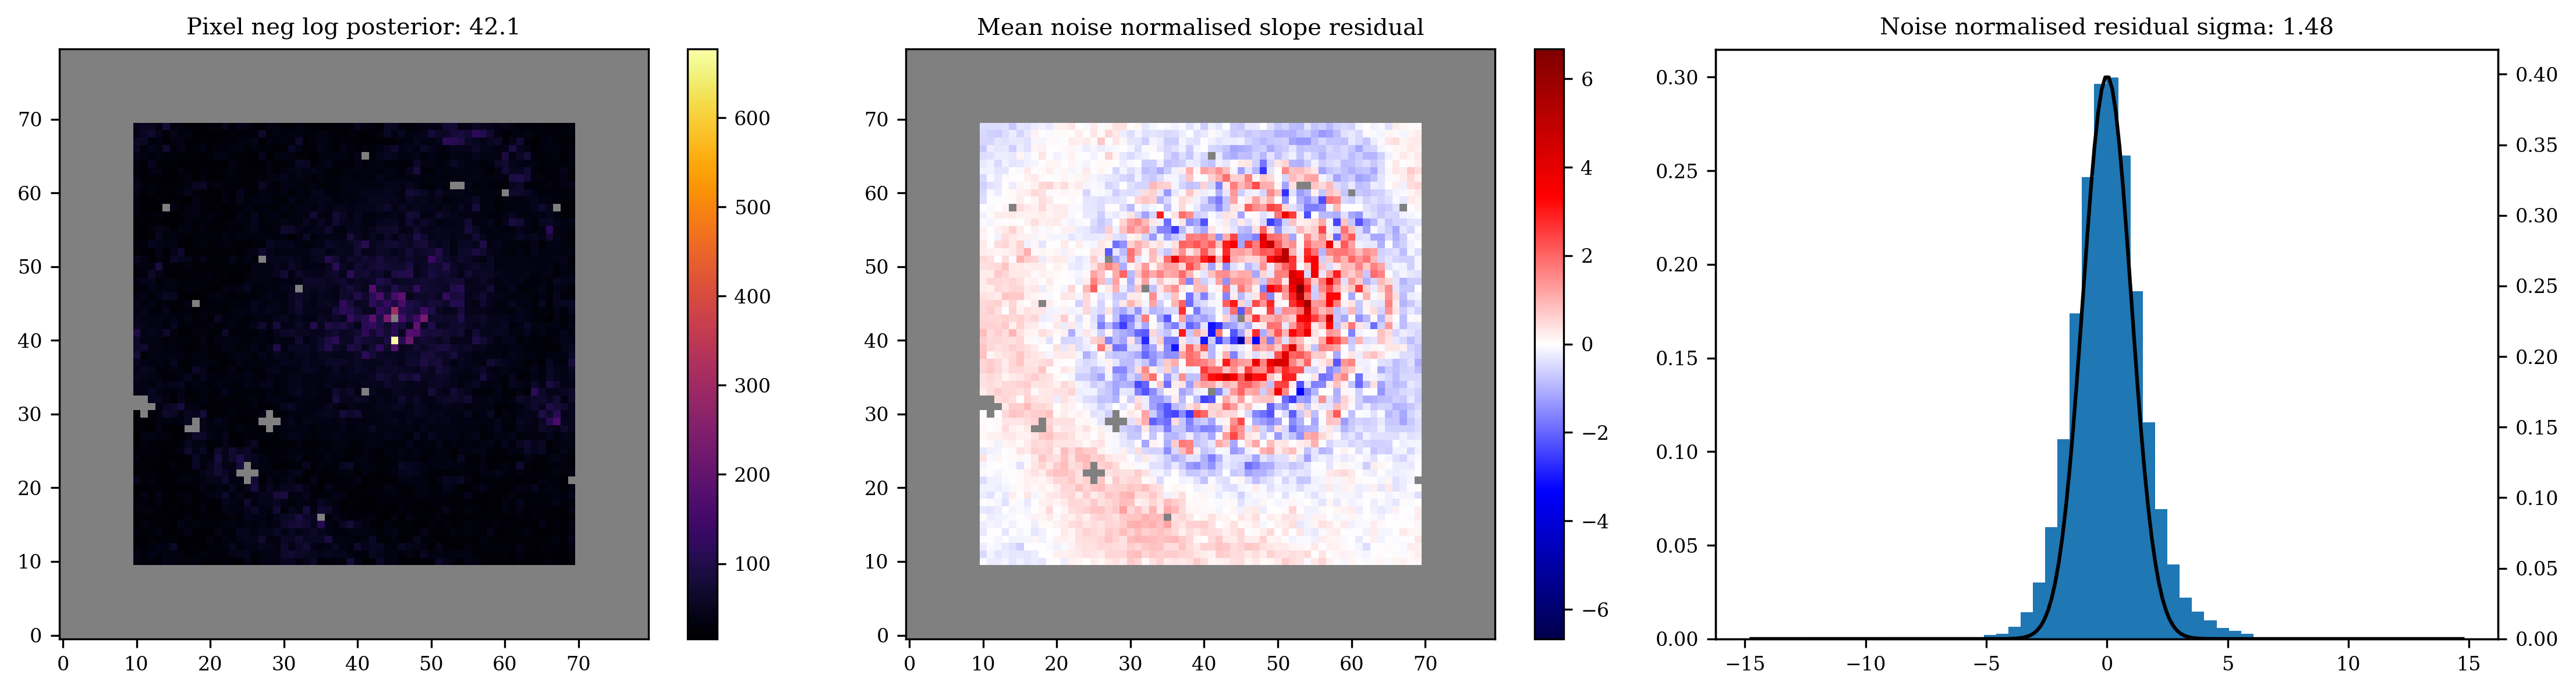

File 01373_023_02_03_1
Star HD 228337
Filter F430M
nints 8
ngroups 12



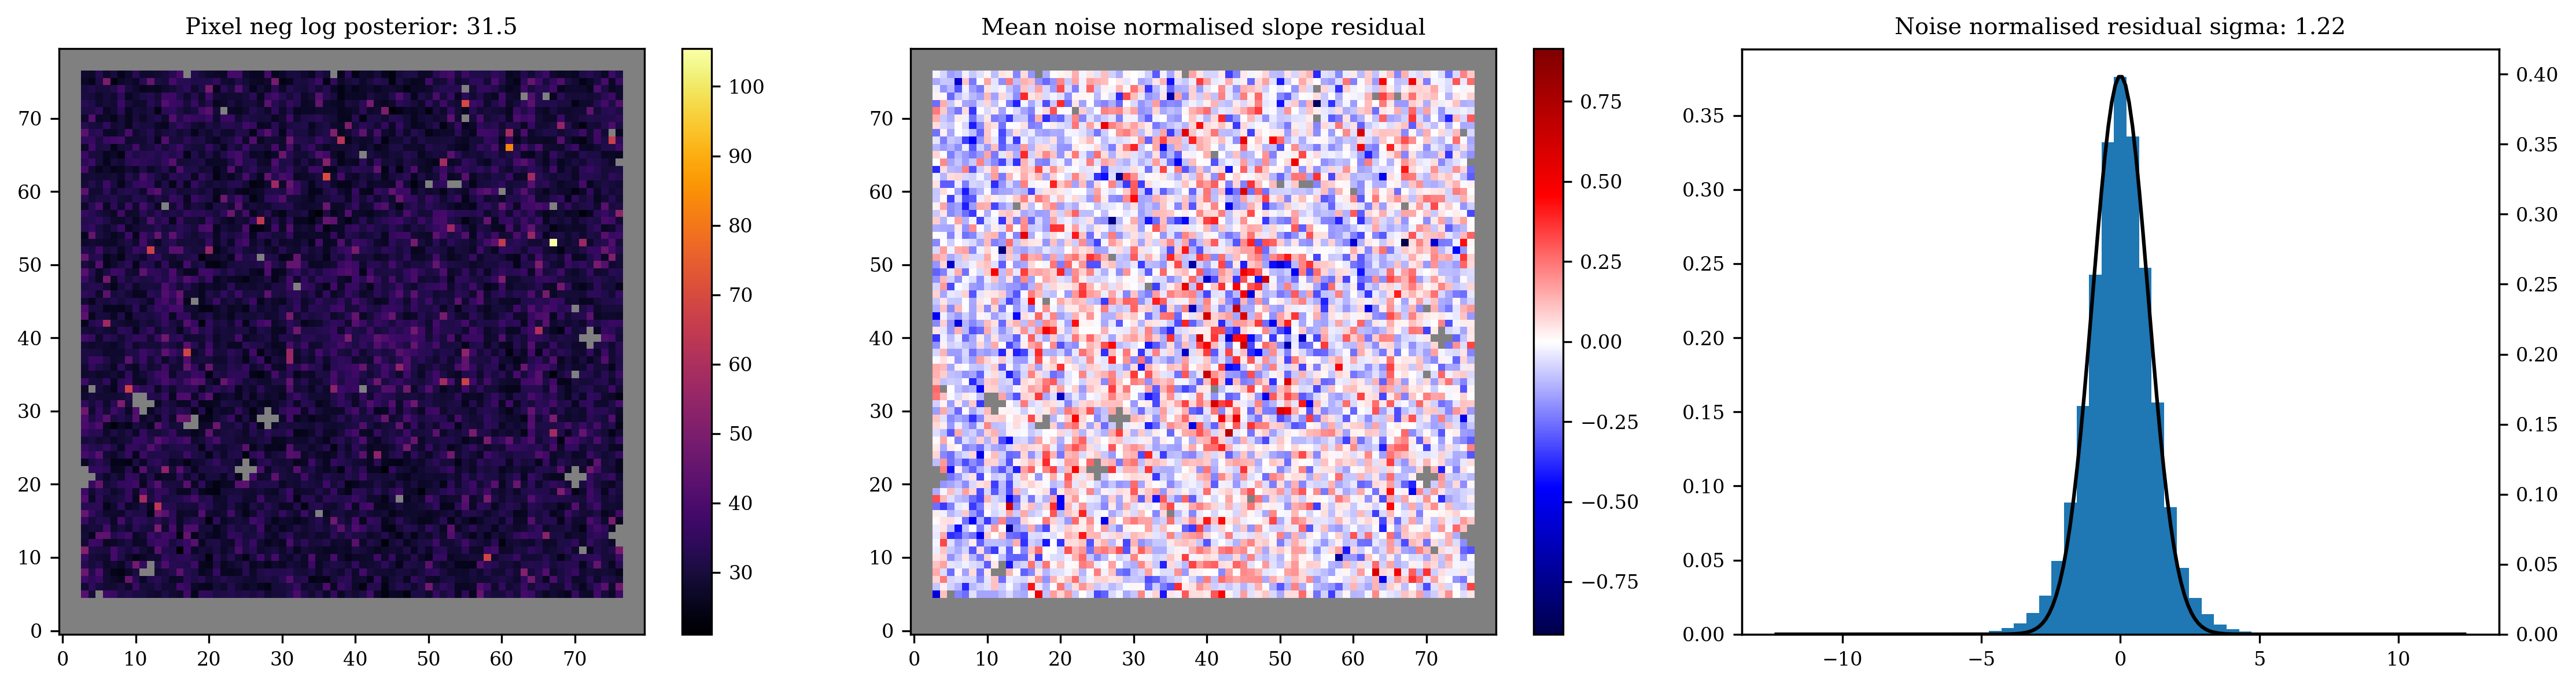

In [13]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in exps:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

Nice. Some of the parameters are not entirely converged, and this can be improved by running the fit for more epochs, or by passing the fit model to another optimiser. We have seen some success with `optimistix.BFGS`. This is especially true of the `spectra` parameter for Io, where you can see the effect of spectral miscalibration in the residuals. 

But this will do nicely for now — let's see our images!

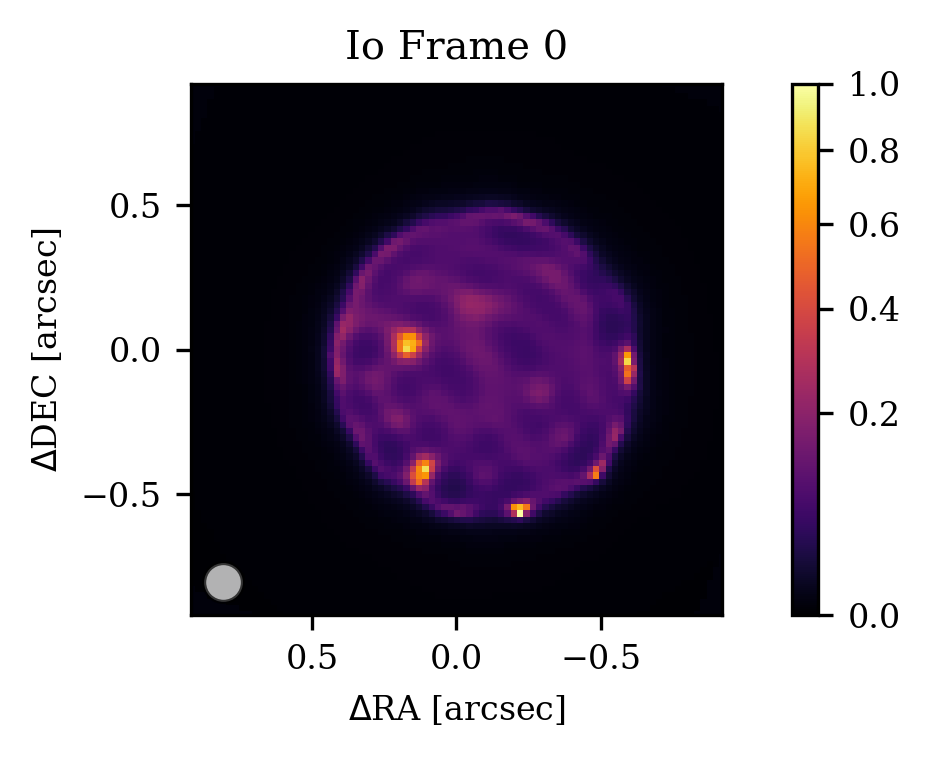

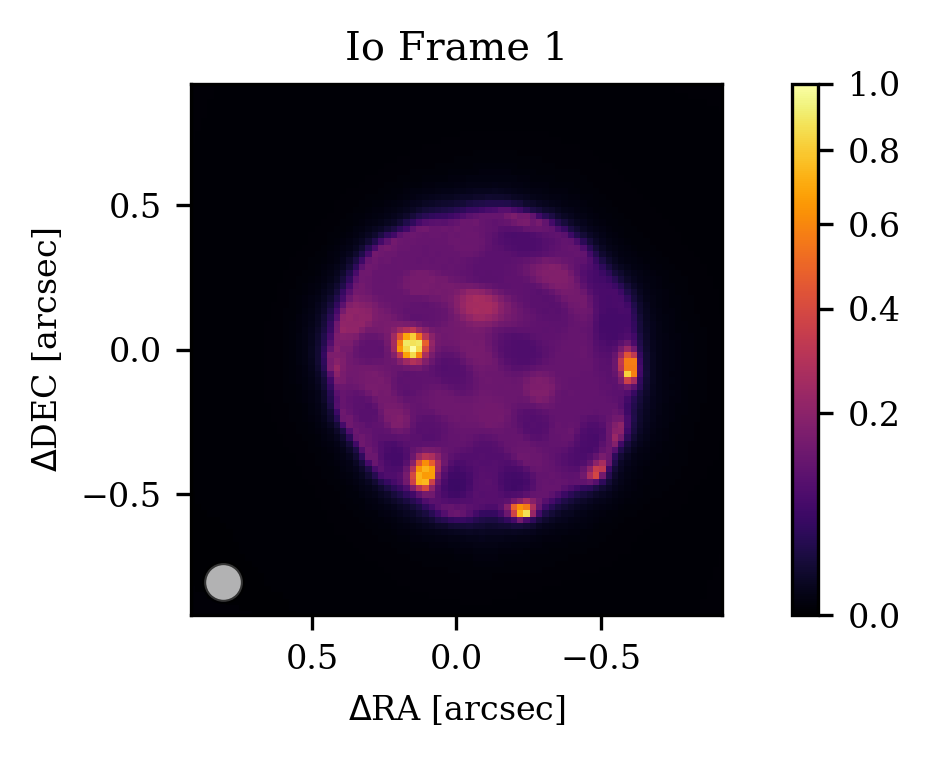

In [14]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
wavel = 4.3e-6  # approximate F430M mean wavelength in meters

for idx, exp in enumerate(exps):

    # only plot science exposures
    if exp.calibrator:
        continue

    dist = result.model.get_distribution(exp, rotate=False)
    fig, ax = plt.subplots(figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist / dist.max(),
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        norm=mpl.colors.PowerNorm(0.6, vmin=0, vmax=1.0),
        diff_lim=0.5 * dlu.rad2arcsec(wavel / optics_diameter),
        scale=1.2,
    )
    fig.colorbar(c0)
    ax.set(title=f"Io Frame {idx}")
    plt.show()